# Neuronales Netz für die California-Housing-Vorhersage

Dieses Notebook zeigt den vollständigen Workflow eines neuronalen Netzes für die Vorhersage von Hauspreisen: Datenvorbereitung, Modelltraining, Bewertung und eine interaktive Testoberfläche für eigene Eingaben.

## Was Sie hier sehen

- Ein Modell, das aus historischen Immobiliendaten lernt.
- Eine Datenvorbereitung mit zusätzlichen geografischen Merkmalen.
- Eine einfache Vergleichsbasis mit einem klassischen linearen Modell.

## 1. Ziel und Aufbau

- Das Modell lernt aus historischen Daten, welche Faktoren den Hauspreis beeinflussen.
- Die Eingaben sind typische Immobilienmerkmale wie Einkommen, Alter, Lage und Raumangebot.
- Die Ausgabe ist eine Vorhersage für den Preiswert MedHouseVal.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow.keras as keras
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 42
tf.keras.utils.set_random_seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Daten laden und vorbereiten

Die Daten werden bereinigt, transformiert und in Trainings- und Testdaten aufgeteilt.

In [3]:
SF_COORDS = (37.7749, -122.4194)
LA_COORDS = (34.0522, -118.2437)
SJ_COORDS = (37.3362, -121.8833)

BASE_FEATURES = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "AveOccup",
    "Population",
    "Latitude",
    "Longitude",
]


def prepare_dataset():
    data = fetch_california_housing()
    df = pd.DataFrame(data=data.data, columns=data.feature_names)
    df[data.target_names[0]] = data.target

    mask_cutoff = (
        (df["MedHouseVal"] < df["MedHouseVal"].max())
        & (df["HouseAge"] < df["HouseAge"].max())
        & (df["MedInc"] < df["MedInc"].max())
    )
    df_clean = df[mask_cutoff].copy()

    clip_columns = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
    for column in clip_columns:
        lower_bound = df_clean[column].quantile(0.01)
        upper_bound = df_clean[column].quantile(0.99)
        df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)

    df_clean["BedrmsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
    df_clean["MedInc"] = np.log1p(df_clean["MedInc"])
    df_clean["Population"] = np.log1p(df_clean["Population"])
    df_clean["AveBedrms"] = np.log1p(df_clean["AveBedrms"])

    df_clean["Dist_to_SF"] = np.sqrt(
        (df_clean["Latitude"] - SF_COORDS[0]) ** 2 + (df_clean["Longitude"] - SF_COORDS[1]) ** 2
    )
    df_clean["Dist_to_LA"] = np.sqrt(
        (df_clean["Latitude"] - LA_COORDS[0]) ** 2 + (df_clean["Longitude"] - LA_COORDS[1]) ** 2
    )
    df_clean["Dist_to_SJ"] = np.sqrt(
        (df_clean["Latitude"] - SJ_COORDS[0]) ** 2 + (df_clean["Longitude"] - SJ_COORDS[1]) ** 2
    )

    feature_frame = df_clean[BASE_FEATURES + ["BedrmsPerRoom", "Dist_to_SF", "Dist_to_LA", "Dist_to_SJ"]]
    target = df_clean["MedHouseVal"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        feature_frame, target, test_size=0.2, random_state=SEED
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler, feature_frame.columns.tolist()


df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler, feature_columns = prepare_dataset()
print(f"Zeilen nach Bereinigung: {len(df_clean)}")
print(f"Trainingsdaten: {X_train_scaled.shape}")
print(f"Testdaten: {X_test_scaled.shape}")
print(f"Verwendete Features ({len(feature_columns)}): {', '.join(feature_columns)}")
print("\nBeispiel der vorbereiteten Daten:")
df_clean[["MedHouseVal", "MedInc", "HouseAge", "Latitude", "Longitude"]].head()

Zeilen nach Bereinigung: 18570
Trainingsdaten: (14856, 12)
Testdaten: (3714, 12)
Verwendete Features (12): MedInc, HouseAge, AveRooms, AveBedrms, AveOccup, Population, Latitude, Longitude, BedrmsPerRoom, Dist_to_SF, Dist_to_LA, Dist_to_SJ

Beispiel der vorbereiteten Daten:


,MedHouseVal,MedInc,HouseAge,Latitude,Longitude
0,4.526,2.232720,41.0,37.88,-122.23
1,3.585,2.230165,21.0,37.86,-122.22
8,2.267,1.125059,42.0,37.84,-122.26
15,1.400,1.139434,50.0,37.85,-122.26
18,1.587,1.095641,50.0,37.84,-122.26


## 3. Modell definieren und trainieren

Das Netzwerk besteht aus mehreren dichten Schichten, Batch-Normalisierung und Dropout, damit es gut generalisieren kann.

In [4]:
def build_model(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


model = build_model(X_train_scaled.shape[1])

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ],
    verbose=0,
)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Neuronales Netz")
print(f"MSE: {model.evaluate(X_test_scaled, y_test, verbose=0)[0]:.2f}")
print(f"MAE: {model.evaluate(X_test_scaled, y_test, verbose=0)[1]:.2f}")
print("\nBaseline: Lineares Modell")
print(f"MAE: {baseline_mae:.2f}")
print(f"R²: {baseline_r2:.4f}")

E0000 00:00:1785089635.601498   80697 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Neuronales Netz
MSE: 0.24
MAE: 0.32

Baseline: Lineares Modell
MAE: 0.44
R²: 0.6289


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE auf dem Testset: 0.22
MAE auf dem Testset: 0.32
R² auf dem Testset: 0.7615


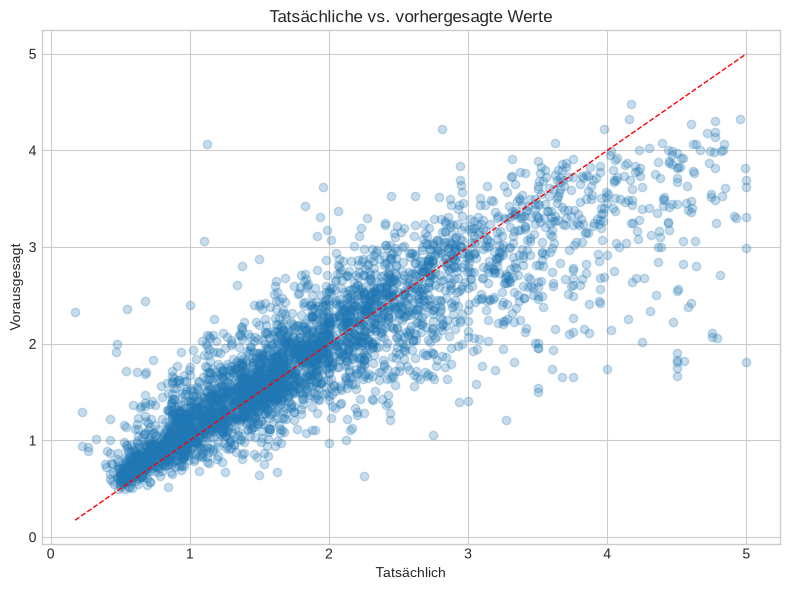

In [5]:
# Modellbewertung
predictions = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MSE auf dem Testset: {mse:.2f}")
print(f"MAE auf dem Testset: {mae:.2f}")
print(f"R² auf dem Testset: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.25, color="#1f77b4")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1)
plt.title("Tatsächliche vs. vorhergesagte Werte")
plt.xlabel("Tatsächlich")
plt.ylabel("Vorausgesagt")
plt.tight_layout()
plt.show()

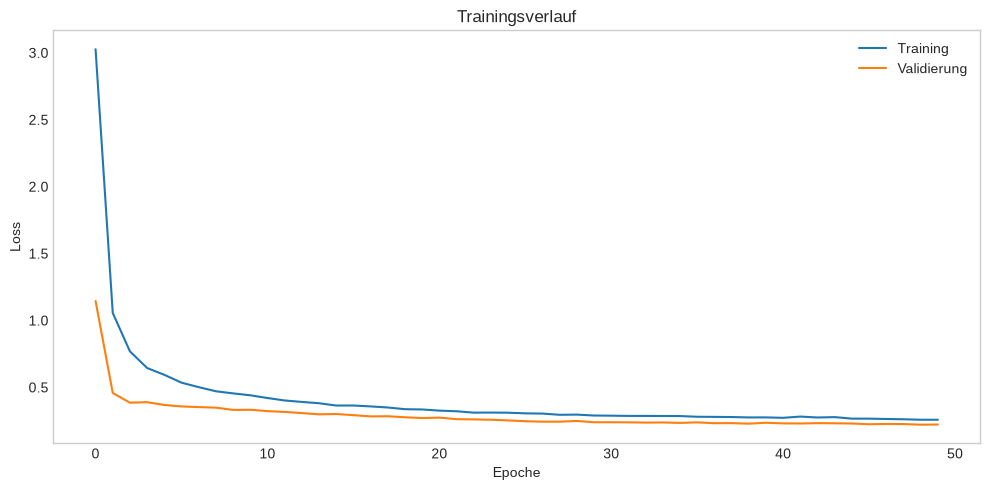

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validierung")
plt.title("Trainingsverlauf")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 4. Finale Leistungsbewertung

Die finale Bewertung vergleicht das neuronale Netz direkt mit dem linearen Basismodell auf dem Testset.

Modellvergleich auf dem Testset
----------------------------------------
Neuronales Netz:
  MSE : 0.22
  MAE : 0.32
  R²  : 0.7615

Lineares Basismodell:
  MSE : 0.35
  MAE : 0.44
  R²  : 0.6289

Relativer Vorteil gegenüber dem linearen Modell:
  MAE verbessert um 0.12 (27.0 %)
  R² verbessert um 0.1326


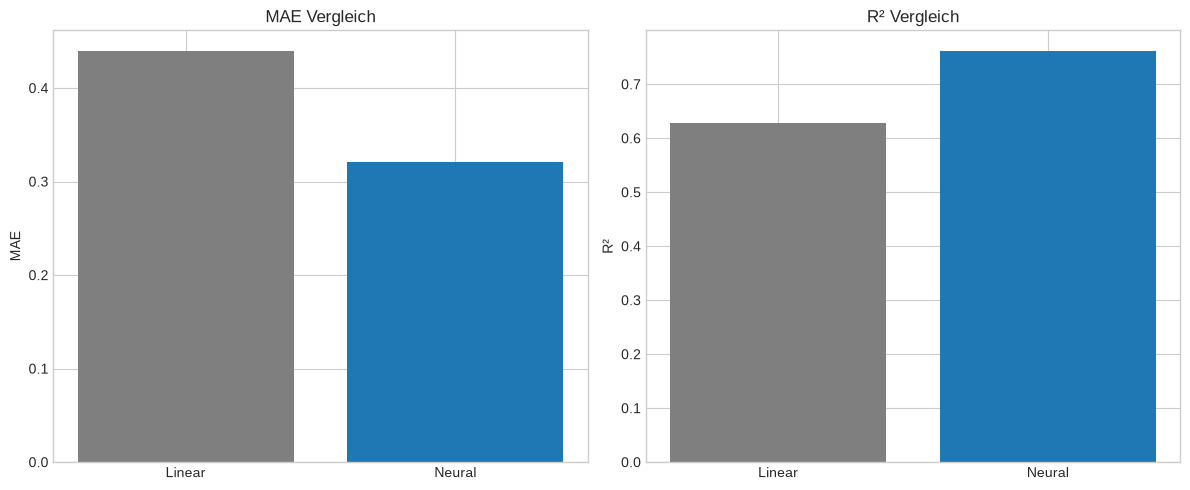

In [9]:
# Finale Leistungsbewertung
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Modellvergleich auf dem Testset")
print("----------------------------------------")
print("Neuronales Netz:")
print(f"  MSE : {mse:.2f}")
print(f"  MAE : {mae:.2f}")
print(f"  R²  : {r2:.4f}")
print("")
print("Lineares Basismodell:")
print(f"  MSE : {baseline_mse:.2f}")
print(f"  MAE : {baseline_mae:.2f}")
print(f"  R²  : {baseline_r2:.4f}")

mae_gain = baseline_mae - mae
r2_gain = r2 - baseline_r2
print("")
print("Relativer Vorteil gegenüber dem linearen Modell:")
print(f"  MAE verbessert um {mae_gain:.2f} ({mae_gain / baseline_mae * 100:.1f} %)")
print(f"  R² verbessert um {r2_gain:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(["Linear", "Neural"], [baseline_mae, mae], color=["#7f7f7f", "#1f77b4"])
plt.title("MAE Vergleich")
plt.ylabel("MAE")

plt.subplot(1, 2, 2)
plt.bar(["Linear", "Neural"], [baseline_r2, r2], color=["#7f7f7f", "#1f77b4"])
plt.title("R² Vergleich")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

## 5. Zusammenfassung

Dieses Notebook zeigt den Workflow eines neuronales Netzes: Datenaufbereitung, Modelltraining, Bewertung und anschließende Vorhersage.